# Data Mining Lab 2
## Өгөгдлийн шинж чанар: Тайлбарлалт, Дүрслэл ба Төсөөлөл
**Dataset:** StudentsPerformance.csv

**Зорилго:**  
Энэхүү лабораторийн ажлыг дуусгасны дараа оюутан:
- Өгөгдлийн объект, аттрибутын тухай ойлголтыг бодит dataset дээр ашиглаж сурна  
- Статистик тайлбарлалтын аргуудыг (төв хандлага, хэлбэлзэл, тархалтын хэлбэр) тооцоолж чадна  
- Өгөгдлийг график аргаар зөв дүрслэнэ  
- Өгөгдлийн объектуудын хоорондын төсөө (similarity) ба ялгааг (dissimilarity) хэмжинэ  
- Нормализацийн аргуудыг (Min-Max, Z-score) ойлгож, хэрэглэнэ  



In [31]:
%pip install numpy matplotlib pandas scipy scikit-learn

1367.65s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


  Using cached scikit_learn-1.7.2-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
Using cached scikit_learn-1.7.2-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (9.7 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn]0m 3/4 [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)


## 0) Dataset унших

**StudentsPerformance.csv** файлыг ашиглана.



In [3]:
df = pd.read_csv("StudentsPerformance.csv")
df.head()


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## 1) Өгөгдлийн объект ба аттрибут (Data Object & Attribute)

- Dataset дахь **мөр бүр** нэг өгөгдлийн объект (нэг оюутан) юм: x=(a₁, a₂, …, aₙ)  
- Dataset дахь **багана бүр** нэг аттрибут (feature)  

### 1.1 Dataset-ийн бүтэц
- Хэдэн объект (мөр), хэдэн аттрибут (багана) вэ?  
- Аль аттрибут numeric, аль нь categorical вэ?



In [4]:
print("Shape (objects, attributes):", df.shape)
print("Attributes:", list(df.columns))
df.dtypes


Shape (objects, attributes): (1000, 8)
Attributes: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']


gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object

### 1.2 Missing болон duplicate шалгах

- Аль аттрибутад missing value байна вэ?  
- Давхардсан объект (мөр) байгаа эсэх?



In [5]:
# Missing values
df.isna().sum()


gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [6]:
# Duplicate rows
df.duplicated().sum()


np.int64(0)

### 1.3 Numeric ба Categorical аттрибутууд



In [7]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

print("Numeric columns:", list(num_cols))
print("Categorical columns:", list(cat_cols))


Numeric columns: ['math score', 'reading score', 'writing score']
Categorical columns: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


### TASK A: Аттрибутын хэмжээсийн түвшин (Measurement Level)

Лекцийн дагуу (**Nominal, Ordinal, Interval, Ratio**) доорх аттрибут бүрийг ангилж, шалтгаанаа бичнэ үү:

| Аттрибут | Төрөл (Nominal/Ordinal/Interval/Ratio) | Шалтгаан |
|---|---|---|
| gender | | |
| race/ethnicity | | |
| parental level of education | | |
| lunch | | |
| test preparation course | | |
| math score | | |
| reading score | | |
| writing score | | |

**Санамж:** score-ууд нь 0 цэгтэй (0 оноо = мэдлэггүй гэсэн үг биш ч бодит тоон утга) тул ихэвчлэн ratio гэж авч үздэг, харин `parental level of education` дараалалтай тул ordinal.



In [12]:
# энд өөрийн ангиллаа код/тайлбар хэлбэрээр баталгаажуулж болно
for col in df.columns:
    print(f"{col}:{df[col].dtype}")
    print(df[col].unique()[:5])
    print()

gender:object
['female' 'male']

race/ethnicity:object
['group B' 'group C' 'group A' 'group D' 'group E']

parental level of education:object
["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school']

lunch:object
['standard' 'free/reduced']

test preparation course:object
['none' 'completed']

math score:int64
[72 69 90 47 76]

reading score:int64
[72 90 95 57 78]

writing score:int64
[74 88 93 44 75]



In [14]:
classification_df = pd.DataFrame({
    'Attribute': ['gender', 'race/ethnicity', 'parental level of education', 
                  'lunch', 'test preparation course', 'math score', 'reading score', 'writing score'],
    'Measurement Level': ['Nominal', 'Nominal', 'Ordinal', 
                          'Nominal', 'Nominal', 'Ratio', 'Ratio', 'Ratio'],
    'Reason': [
        'Эрэмбэгүй категори (female, male)',
        'Эрэмбэгүй бүлгүүд',
        'Шатлал бүхий эрэмбэтэй боловсролын зэрэг',
        'Эрэмбэгүй категори (standard, free/reduced)',
        'Эрэмбэгүй 2 төлөвтэй (none, completed)',
        '0 цэг бүхий бодит тоон утга',
        '0 цэг бүхий бодит тоон утга',
        '0 цэг бүхий бодит тоон утга'
    ]
})
classification_df

,Attribute,Measurement Level,Reason
0,gender,Nominal,"Эрэмбэгүй категори (female, male)"
1,race/ethnicity,Nominal,Эрэмбэгүй бүлгүүд
2,parental level of education,Ordinal,Шатлал бүхий эрэмбэтэй боловсролын зэрэг
3,lunch,Nominal,"Эрэмбэгүй категори (standard, free/reduced)"
4,test preparation course,Nominal,"Эрэмбэгүй 2 төлөвтэй (none, completed)"
5,math score,Ratio,0 цэг бүхий бодит тоон утга
6,reading score,Ratio,0 цэг бүхий бодит тоон утга
7,writing score,Ratio,0 цэг бүхий бодит тоон утга


## 2) Статистик тайлбарлалт (Statistical Description)

### 2.1 Ерөнхий статистик



In [15]:
df.describe()


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


### 2.2 Төв хандлага: Mean, Median, Mode

- **Mean** — бүх утгыг ашигладаг ч outlier-д мэдрэмтгий  
- **Median** — эрэмбэлсэн дундах утга, outlier-д тэсвэртэй  
- **Mode** — хамгийн олон давтагдсан утга



In [16]:
for col in num_cols:
    print(f"{col:15s} mean={df[col].mean():.2f}  median={df[col].median():.2f}  mode={df[col].mode()[0]}")


math score      mean=66.09  median=66.00  mode=65
reading score   mean=69.17  median=70.00  mode=72
writing score   mean=68.05  median=69.00  mode=74


### 2.3 Хэлбэлзэл: Variance, Std



In [17]:
for col in num_cols:
    print(f"{col:15s} variance={df[col].var():.2f}  std={df[col].std():.2f}")


math score      variance=229.92  std=15.16
reading score   variance=213.17  std=14.60
writing score   variance=230.91  std=15.20


### 2.4 Тархалтын хэлбэр (Distribution Shape)

Лекц ёсоор:
- Symmetric: Mean ≈ Median ≈ Mode  
- Left-skewed: Mean < Median < Mode  
- Right-skewed: Mode < Median < Mean

Доорх код Mean ба Median-ийг харьцуулж, тархалтын хэлбэрийг тодорхойлно.



In [18]:
for col in num_cols:
    m, med = df[col].mean(), df[col].median()
    if abs(m - med) < 0.5:
        shape = "Symmetric"
    elif m < med:
        shape = "Left-skewed"
    else:
        shape = "Right-skewed"
    print(f"{col:15s} mean={m:.2f} median={med:.2f} -> {shape}")


math score      mean=66.09 median=66.00 -> Symmetric
reading score   mean=69.17 median=70.00 -> Left-skewed
writing score   mean=68.05 median=69.00 -> Left-skewed


## 3) Graphик дүрслэл (Visualization)

Лекцэд дурдсанчлан аттрибутын төрлөөс хамааран график сонгоно:

| Өгөгдөл | График |
|---|---|
| Categorical | Bar, Pie |
| Numerical | Histogram, Boxplot |
| Relationship | Scatter |



### 3.1 Bar chart – Categorical аттрибут (race/ethnicity)


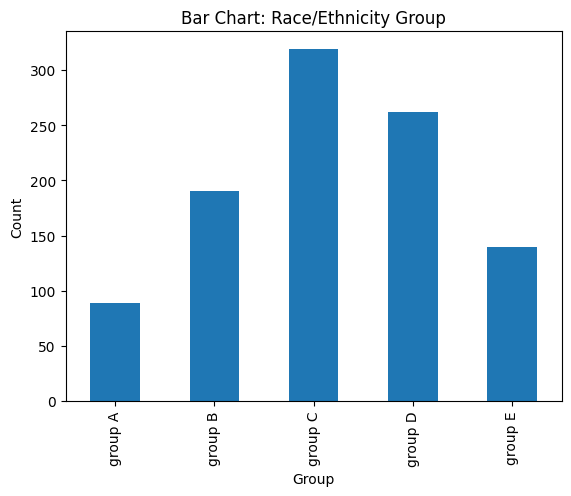

In [19]:
plt.figure()
df['race/ethnicity'].value_counts().sort_index().plot(kind='bar')
plt.title("Bar Chart: Race/Ethnicity Group")
plt.xlabel("Group")
plt.ylabel("Count")
plt.show()


### 3.2 Histogram – Reading score


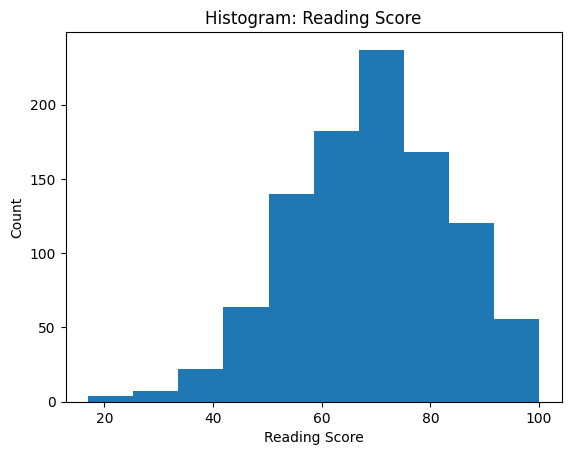

In [20]:
plt.figure()
plt.hist(df['reading score'], bins=10)
plt.title("Histogram: Reading Score")
plt.xlabel("Reading Score")
plt.ylabel("Count")
plt.show()


### 3.3 Boxplot – Test preparation course vs Writing score


<Figure size 640x480 with 0 Axes>

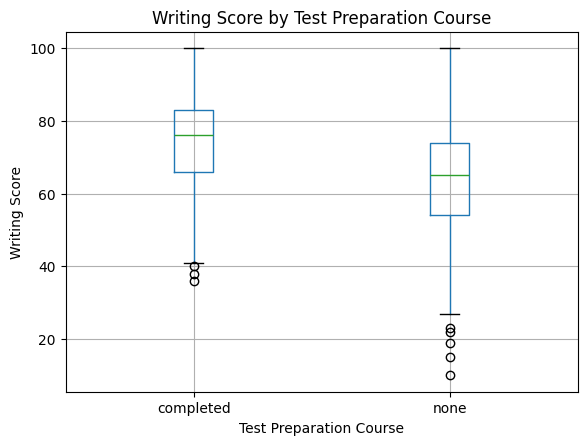

In [21]:
plt.figure()
df.boxplot(column='writing score', by='test preparation course')
plt.title("Writing Score by Test Preparation Course")
plt.suptitle("")
plt.xlabel("Test Preparation Course")
plt.ylabel("Writing Score")
plt.show()


### 3.4 Scatter – Reading vs Writing score


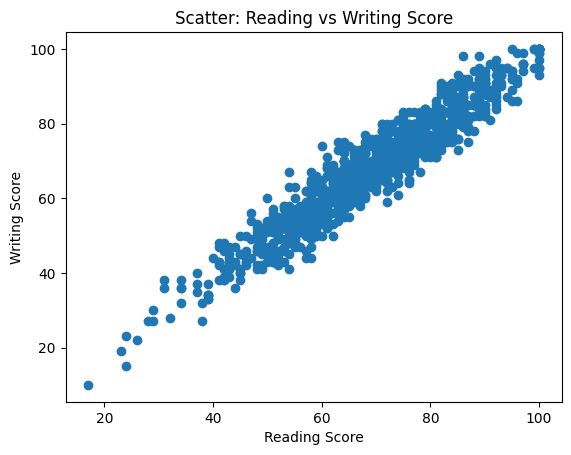

In [22]:
plt.figure()
plt.scatter(df['reading score'], df['writing score'])
plt.title("Scatter: Reading vs Writing Score")
plt.xlabel("Reading Score")
plt.ylabel("Writing Score")
plt.show()


## 4) Төсөө ба ялгаа (Similarity & Dissimilarity)

- **Euclidean distance:** d(x,y) = sqrt(Σ(xᵢ - yᵢ)²)  
- **Manhattan distance:** d(x,y) = Σ|xᵢ - yᵢ|  

Доорх жишээнд эхний 3 оюутны (`math score`, `reading score`, `writing score`) утгуудыг ашиглан хос бүрийн зайг тооцооно.



In [23]:
from itertools import combinations

sample = df.loc[0:2, ['math score', 'reading score', 'writing score']]
sample.index = ['A', 'B', 'C']
sample


,math score,reading score,writing score
A,72,72,74
B,69,90,88
C,90,95,93


In [24]:
def euclidean(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

def manhattan(a, b):
    return np.sum(np.abs(a - b))

for i, j in combinations(sample.index, 2):
    a, b = sample.loc[i].values, sample.loc[j].values
    print(f"{i}-{j}:  Euclidean={euclidean(a, b):.2f}   Manhattan={manhattan(a, b):.2f}")


A-B:  Euclidean=23.00   Manhattan=35.00
A-C:  Euclidean=34.84   Manhattan=60.00
B-C:  Euclidean=22.16   Manhattan=31.00


### TASK B: Хамгийн төстэй оюутнууд

1. Дээрх гурван оюутны аль хос нь хамгийн бага Euclidean distance-той, өөрөөр хэлбэл хамгийн **төстэй** вэ?  
2. Manhattan distance-аар бодоход хариулт өөрчлөгдөж байна уу?  
3. Өөрийн сонгосон 3 өөр оюутнаар дахин тооцоолж, дүгнэлт хий.



In [ ]:
from scipy.spatial.distance import euclidean, cityblock
from sklearn.preprocessing import MinMaxScaler 
# 1. Онооны багануудыг сонгох
score_cols = ['math score', 'reading score', 'writing score']

# ==========================================
# 1 & 2. Эхний 3 оюутныг тооцоолох (Оюутан 0, 1, 2)
# ==========================================
s0 = df.loc[0, score_cols].values
s1 = df.loc[1, score_cols].values
s2 = df.loc[2, score_cols].values

pairs = {
    "(Оюутан 0, Оюутан 1)": (s0, s1),
    "(Оюутан 0, Оюутан 2)": (s0, s2),
    "(Оюутан 1, Оюутан 2)": (s1, s2)
}

results_1 = []
for pair_name, (a, b) in pairs.items():
    d_euc = euclidean(a, b)       
    d_man = cityblock(a, b)       
    results_1.append({
        'Хос': pair_name,
        'Euclidean Distance': round(d_euc, 2),
        'Manhattan Distance': d_man
    })

res_df1 = pd.DataFrame(results_1)
print("=== ЭХНИЙ 3 ОЮУТНЫ ЗАЙН ТООЦООЛОЛ ===")
print(res_df1)

# Хамгийн төстэй (хамгийн бага зайтай) хосыг тодорхойлох
min_euc_pair = res_df1.loc[res_df1['Euclidean Distance'].idxmin()]['Хос']
min_man_pair = res_df1.loc[res_df1['Manhattan Distance'].idxmin()]['Хос']
print(f"\n1. Euclidean distance-аар хамгийн төстэй нь: {min_euc_pair}")
print(f"2. Manhattan distance-аар хамгийн төстэй нь: {min_man_pair}")
if min_euc_pair == min_man_pair:
    print("-> Дүгнэлт: Зайн арга өөрчлөгдсөн ч хамгийн төстэй хос ӨӨРЧЛӨГДСӨНГҮЙ.")
else:
    print("-> Дүгнэлт: Зайн хэмжүүрээс шалтгаалан хамгийн төстэй хос ӨӨРЧЛӨГДСӨН.")

# ==========================================
# 3. Өөрийн сонгосон 3 өөр оюутнаар тооцоолох (Жишээ нь: индекс 10, 20, 30)
# ==========================================
idx_custom = [10, 20, 30]  # Хүсвэл энд дурын өөр 3 индекс тавьж болно
c0 = df.loc[idx_custom[0], score_cols].values
c1 = df.loc[idx_custom[1], score_cols].values
c2 = df.loc[idx_custom[2], score_cols].values

custom_pairs = {
    f"(Оюутан {idx_custom[0]}, Оюутан {idx_custom[1]})": (c0, c1),
    f"(Оюутан {idx_custom[0]}, Оюутан {idx_custom[2]})": (c0, c2),
    f"(Оюутан {idx_custom[1]}, Оюутан {idx_custom[2]})": (c1, c2)
}

results_2 = []
for pair_name, (a, b) in custom_pairs.items():
    results_2.append({
        'Хос': pair_name,
        'Euclidean Distance': round(euclidean(a, b), 2),
        'Manhattan Distance': cityblock(a, b)
    })

res_df2 = pd.DataFrame(results_2)
print("\n=== СОНГОСОН 3 ОЮУТНЫ ЗАЙН ТООЦООЛОЛ ===")
print(res_df2)

=== ЭХНИЙ 3 ОЮУТНЫ ЗАЙН ТООЦООЛОЛ ===
                    Хос  Euclidean Distance  Manhattan Distance
0  (Оюутан 0, Оюутан 1)               23.00                  35
1  (Оюутан 0, Оюутан 2)               34.84                  60
2  (Оюутан 1, Оюутан 2)               22.16                  31

1. Euclidean distance-аар хамгийн төстэй нь: (Оюутан 1, Оюутан 2)
2. Manhattan distance-аар хамгийн төстэй нь: (Оюутан 1, Оюутан 2)
-> Дүгнэлт: Зайн арга өөрчлөгдсөн ч хамгийн төстэй хос ӨӨРЧЛӨГДСӨНГҮЙ.

=== СОНГОСОН 3 ОЮУТНЫ ЗАЙН ТООЦООЛОЛ ===
                      Хос  Euclidean Distance  Manhattan Distance
0  (Оюутан 10, Оюутан 20)               20.25                  34
1  (Оюутан 10, Оюутан 30)               31.70                  53
2  (Оюутан 20, Оюутан 30)               12.45                  19


## 5) Нормализаци (Normalization)

Яагаад хэрэгтэй вэ? Өөр өөр масштабтай аттрибутууд distance тооцооллыг гуйвуулахаас сэргийлнэ.

- **Min-Max normalization:** x' = (x - min) / (max - min)  
- **Z-score normalization:** x' = (x - mean) / std



In [28]:
scores = df[['math score', 'reading score', 'writing score']]

minmax = (scores - scores.min()) / (scores.max() - scores.min())
zscore = (scores - scores.mean()) / scores.std()

print("Min-Max normalized (эхний 5):")
display(minmax.head())
print("\nZ-score normalized (эхний 5):")
display(zscore.head())


Min-Max normalized (эхний 5):


,math score,reading score,writing score
0,0.72,0.662651,0.711111
1,0.69,0.879518,0.866667
2,0.90,0.939759,0.922222
3,0.47,0.481928,0.377778
4,0.76,0.734940,0.722222



Z-score normalized (эхний 5):


,math score,reading score,writing score
0,0.389828,0.193902,0.391296
1,0.191979,1.426762,1.312612
2,1.576922,1.769223,1.641653
3,-1.258913,-0.833482,-1.582952
4,0.653627,0.604855,0.457104


### TASK C: Нормализацийн нөлөө

1. Min-Max normalize хийсэн эхний 3 оюутны хооронд Euclidean distance-ийг дахин тооцоол.  
2. Normalize хийхээс өмнөх distance-тай харьцуулж, ялгааг тайлбарла (үгээр).  
3. Аль тохиолдолд normalization хийх нь **зайлшгүй шаардлагатай** вэ? (жишээ өг)



In [ ]:
codescore_cols = ['math score', 'reading score', 'writing score']

scaler = MinMaxScaler()
df_normalized = pd.DataFrame(scaler.fit_transform(df[score_cols]), columns=score_cols)

s0_norm = df_normalized.loc[0].values
s1_norm = df_normalized.loc[1].values
s2_norm = df_normalized.loc[2].values
s0_raw = df.loc[0, score_cols].values
s1_raw = df.loc[1, score_cols].values
s2_raw = df.loc[2, score_cols].values

pairs = [
    ("(Оюутан 0, Оюутан 1)", (s0_raw, s1_raw), (s0_norm, s1_norm)),
    ("(Оюутан 0, Оюутан 2)", (s0_raw, s2_raw), (s0_norm, s2_norm)),
    ("(Оюутан 1, Оюутан 2)", (s1_raw, s2_raw), (s1_norm, s2_norm)),
]

comparison_results = []
for name, raw_pair, norm_pair in pairs:
    d_raw = euclidean(raw_pair[0], raw_pair[1])
    d_norm = euclidean(norm_pair[0], norm_pair[1])
    comparison_results.append({
        'Хос': name,
        'Raw Euclidean Distance': round(d_raw, 4),
        'Normalized Euclidean Distance': round(d_norm, 4)
    })

comparison_df = pd.DataFrame(comparison_results)
print("=== НОРМАЛИЗАЦИЙН ӨМНӨХ БОЛОН ДАРААХ ЗАЙН ХАРЬЦУУЛАЛТ ===")
print(comparison_df)


In [ ]:
codescore_cols = ['math score', 'reading score', 'writing score']
scaler = MinMaxScaler()
df_normalized = pd.DataFrame(scaler.fit_transform(df[score_cols]), columns=score_cols)

s0_norm = df_normalized.loc[0].values
s1_norm = df_normalized.loc[1].values
s2_norm = df_normalized.loc[2].values

s0_raw = df.loc[0, score_cols].values
s1_raw = df.loc[1, score_cols].values
s2_raw = df.loc[2, score_cols].values

pairs = [
    ("(Оюутан 0, Оюутан 1)", (s0_raw, s1_raw), (s0_norm, s1_norm)),
    ("(Оюутан 0, Оюутан 2)", (s0_raw, s2_raw), (s0_norm, s2_norm)),
    ("(Оюутан 1, Оюутан 2)", (s1_raw, s2_raw), (s1_norm, s2_norm)),
]

comparison_results = []
for name, raw_pair, norm_pair in pairs:
    d_raw = euclidean(raw_pair[0], raw_pair[1])
    d_norm = euclidean(norm_pair[0], norm_pair[1])
    comparison_results.append({
        'Хос': name,
        'Raw Euclidean Distance': round(d_raw, 4),
        'Normalized Euclidean Distance': round(d_norm, 4)
    })

comparison_df = pd.DataFrame(comparison_results)
print("=== НОРМАЛИЗАЦИЙН ӨМНӨХ БОЛОН ДАРААХ ЗАЙН ХАРЬЦУУЛАЛТ ===")
print(comparison_df)


=== НОРМАЛИЗАЦИЙН ӨМНӨХ БОЛОН ДАРААХ ЗАЙН ХАРЬЦУУЛАЛТ ===
                    Хос  Raw Euclidean Distance  Normalized Euclidean Distance
0  (Оюутан 0, Оюутан 1)                 23.0000                         0.2686
1  (Оюутан 0, Оюутан 2)                 34.8425                         0.3921
2  (Оюутан 1, Оюутан 2)                 22.1585                         0.2254


## TASK D: Feature Analysis

Доорх асуултуудад **Python код бичиж** хариулна уу.

1. Аль categorical feature (`gender`, `lunch`, `test preparation course`) нь math score-т хамгийн их ялгаа үүсгэж байна вэ?  
2. Тухайн feature бүрээр math score-ийн **дундаж**-ийг тооцоол (`groupby()` + `mean()`).  
3. Гурван score-ийн дундаас аль нь хамгийн их **variance**-тай вэ, энэ нь юуг илэрхийлж болох вэ?



In [ ]:
features = ['gender', 'lunch', 'test preparation course']
diff_results = {}

print("=== 1 & 2. FEATURE БҮРЭЭР MATH SCORE-ИЙН ДУНДАЖ БОЛОН ЗӨРҮҮ ===")
for col in features:
    group_mean = df.groupby(col)['math score'].mean()
    print(f"\n[{col}]-ийн дундаж math score:")
    print(round(group_mean, 2))
    
    diff = group_mean.max() - group_mean.min()
    diff_results[col] = diff
    print(f"-> Бүлэг хоорондын ялгаа (зөрүү): {diff:.2f} оноо")

max_feature = max(diff_results, key=diff_results.get)
print(f"\n=> 1-р асуултын хариу: math score-т хамгийн их ялгаа үүсгэж буй feature нь: '{max_feature}' (зөрүү: {diff_results[max_feature]:.2f} оноо)\n")

scores = ['math score', 'reading score', 'writing score']
variances = df[scores].var()

print("=== 3. СКОР БҮРИЙН VARIANCE (ДИСПЕРС) ===")
print(round(variances, 2))

max_var_score = variances.idxmax()
print(f"\n=> 3-р асуултын хариу: Хамгийн их variance-тай нь: '{max_var_score}' ({variances[max_var_score]:.2f})")


=== 1 & 2. FEATURE БҮРЭЭР MATH SCORE-ИЙН ДУНДАЖ БОЛОН ЗӨРҮҮ ===

[gender]-ийн дундаж math score:
gender
female    63.63
male      68.73
Name: math score, dtype: float64
-> Бүлэг хоорондын ялгаа (зөрүү): 5.10 оноо

[lunch]-ийн дундаж math score:
lunch
free/reduced    58.92
standard        70.03
Name: math score, dtype: float64
-> Бүлэг хоорондын ялгаа (зөрүү): 11.11 оноо

[test preparation course]-ийн дундаж math score:
test preparation course
completed    69.70
none         64.08
Name: math score, dtype: float64
-> Бүлэг хоорондын ялгаа (зөрүү): 5.62 оноо

=> 1-р асуултын хариу: math score-т хамгийн их ялгаа үүсгэж буй feature нь: 'lunch' (зөрүү: 11.11 оноо)

=== 3. СКОР БҮРИЙН VARIANCE (ДИСПЕРС) ===
math score       229.92
reading score    213.17
writing score    230.91
dtype: float64

=> 3-р асуултын хариу: Хамгийн их variance-тай нь: 'writing score' (230.91)


# Data Mining Lab 2 Тайлан
## Өгөгдлийн шинж чанар: Тайлбарлалт, Дүрслэл ба Төсөөлөл

**Нэр:**  
**Оюутны код:**  
**Анги / Бүлэг:**  
**Огноо:**  

---

## 1. Dataset-ийн ерөнхий мэдээлэл
- Объектын (мөр) тоо:
- Аттрибутын (багана) тоо:
- Numeric аттрибутууд:
- Categorical аттрибутууд:

---

## 2. Аттрибутын хэмжээсийн түвшин
Дээрх TASK A хүснэгтийг энд гүйцээж бичнэ үү.

---

## 3. Статистик тайлбарлалт
- Mean, Median, Mode-ийн харьцуулалтаас ажиглагдсан:
- Хамгийн их variance-тай score:
- Тархалтын хэлбэр (symmetric/skewed) ажиглалт:

---

## 4. Дүрслэл
- Histogram-аас ажиглагдсан pattern:
- Boxplot-оос ажиглагдсан ялгаа:
- Scatter-ээс ажиглагдсан хамаарал:

---

## 5. Төсөө ба ялгаа
- Хамгийн төстэй оюутнууд ба тэдгээрийн distance утга:
- Euclidean ба Manhattan-ийн ялгаа ажиглалт:

---

## 6. Нормализаци
- Normalization хийхээс өмнө/дараах distance ялгаа:
- Normalization ямар тохиолдолд зайлшгүй шаардлагатай вэ:

---

## 7. Ерөнхий дүгнэлт
Энэ dataset дээр ажилласнаас ямар дүгнэлтэд хүрэв? (3-5 өгүүлбэр)
